# Vegemite Production — End-to-End Training Notebook

**Theme 3: Product Manufacturing / Mechanical Engineering**

**Project Overview:**
This notebook implements an end-to-end machine learning pipeline for quality prediction and downtime detection in the Vegemite production process.

**Pipeline Structure:**
1. Data Loading — Integration of Main, Infinity (Yeast/Paste), Weekly, and Set Point data
2. Exploratory Data Analysis (EDA) — Statistical analysis of class balance and sensor distributions
3. Preprocessing — Missing value imputation and chronological data alignment
4. Feature Engineering — Dynamic windowing (Rolling/Difference) per product part
5. Train/Test Split — Chronological 70/15/15 split to prevent data leakage
6. Handle Imbalance — Adaptive SMOTE for minority quality classes
7. Train Multiple Models — Multi-algorithm benchmarking (XGBoost, LightGBM, CatBoost, RandomForest)
8. Evaluation — Performance analysis using Accuracy, F1-Score, and ROC-AUC
9. Model Comparison — Benchmarking and selection of the optimal algorithm
10. Feature Importance — Identification of key process drivers
11. Save Best Model — Persistence of models and deployment artifacts

---
## 1. Setup and Environment

Initial library imports and data path configuration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

def brute_search_data():
    """Universal scanner to locate dataset directories."""
    paths = {'MAIN': None, 'INFINITY': None, 'WEEKLY': None, 'DOWNTIME': None}
    print('--- Data Discovery Process ---')
    for root_dir in ['/kaggle/input', '.', '..']:
        if not os.path.exists(root_dir): continue
        for r, dirs, files in os.walk(root_dir):
            files_lower = [f.lower() for f in files]
            if 'good.csv' in files_lower:
                paths['MAIN'] = r
                print(f'  [Found] Main Production data: {r}')
            if any('infinity' in f and 'yeast' in f for f in files_lower):
                paths['INFINITY'] = r
                print(f'  [Found] Infinity process data: {r}')
            if any('week' in f for f in files_lower) and paths['WEEKLY'] is None:
                paths['WEEKLY'] = r
                print(f'  [Found] Weekly sensor data: {r}')
            if any(('prep' in f and 'dt' in f) or 'downtime' in f for f in files_lower):
                paths['DOWNTIME'] = r
                print(f'  [Found] Downtime logs: {r}')

    if not paths['MAIN']:
        print('Warning: Primary dataset (good.csv) not found.')
    return paths

PATHS = brute_search_data()
print('Environment setup complete.')

--- Data Discovery Process ---
  [Found] Main Production data: /kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/data_02_07_2019-26-06-2020
  [Found] Infinity process data: /kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Infinity Data 01_05_20 - 30_06_20
  [Found] Downtime logs: /kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Downtime
  [Found] Main Production data: ../input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/data_02_07_2019-26-06-2020
  [Found] Infinity process data: ../input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Infinity Data 01_05_20 - 30_06_20
  [Found] Downtime logs: ../input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Downtime
Environment setup complete.


---
## Core Functions

Implementation of helper utilities for data fusion and algorithm benchmarking.

In [2]:
# ── SOTA V7.1: Core Functions ───────────────────────────────────────────────

def _get_file(folder, keywords):
    if not folder or not os.path.exists(folder): return None
    for f in os.listdir(folder):
        if all(k.lower() in f.lower() for k in keywords) and f.endswith('.csv'):
            return os.path.join(folder, f)
    return None

def data_loading_fused():
    """Step 1: Precision Load and Fuse. Correctly handles long-format SP files."""
    if not PATHS['MAIN']: return None, None
    print("--- SOTA V7.3: Precision Fusion Starting ---")
    
    # 1. Primary Quality Data
    dfs = []
    for label, kws in [('good', ['good']), ('low_bad', ['low']), ('high_bad', ['high'])]:
        path = _get_file(PATHS['MAIN'], kws)
        if not path: continue
        df = pd.read_csv(path)
        df['quality'] = label
        dfs.append(df)
    if not dfs: return None, None
    df_q = pd.concat(dfs, ignore_index=True)
    ts_col = [c for c in df_q.columns if any(x in c.lower() for x in ['timestamp', 'set time', 'time'])][0]
    df_q['Timestamp'] = pd.to_datetime(df_q[ts_col], format='mixed', dayfirst=True, errors='coerce')
    df_q = df_q.dropna(subset=['Timestamp']).sort_values('Timestamp').reset_index(drop=True)

    # 2. Infinity Data (Yeast + Paste Production)
    if PATHS['INFINITY']:
        inf_files = [f for f in os.listdir(PATHS['INFINITY']) if f.endswith('.csv')]
        for inf_f in inf_files:
            print(f"  [MERGE] Infinity family: {inf_f}")
            df_inf = pd.read_csv(os.path.join(PATHS['INFINITY'], inf_f))
            # Dynamic date/time parsing
            d_col = [c for c in df_inf.columns if 'date' in c.lower()]
            t_col = [c for c in df_inf.columns if 'time' in c.lower()]
            if d_col:
                time_part = df_inf[t_col[0]].astype(str) if t_col else "00:00:00"
                df_inf['Timestamp'] = pd.to_datetime(df_inf[d_col[0]].astype(str) + ' ' + time_part, dayfirst=True, errors='coerce')
                df_inf = df_inf.dropna(subset=['Timestamp']).sort_values('Timestamp')
                num_cols = [c for c in df_inf.select_dtypes(include=[np.number]).columns if 'Batch' not in c and 'Code' not in c]
                df_q = pd.merge_asof(df_q.sort_values('Timestamp'), df_inf[['Timestamp'] + num_cols], on='Timestamp', direction='backward', suffixes=('', f'_inf'))

    # 3. Weekly Sensor Data
    if PATHS['WEEKLY']:
        for wf in os.listdir(PATHS['WEEKLY']):
            if not wf.endswith('.csv'): continue
            print(f"  [MERGE] Weekly Sensors: {wf}")
            p = os.path.join(PATHS['WEEKLY'], wf)
            try: df_w = pd.read_csv(p, encoding='utf-16le')
            except: df_w = pd.read_csv(p)
            t_cols = [c for c in df_w.columns if 'time' in c.lower()]
            if t_cols:
                df_w['Timestamp'] = pd.to_datetime(df_w[t_cols[0]], errors='coerce')
                df_w = df_w.dropna(subset=['Timestamp']).sort_values('Timestamp')
                sensor_cols = [c for c in df_w.columns if any(x in c for x in ['.', '_', 'VEG']) and c != 'Timestamp']
                df_q = pd.merge_asof(df_q.sort_values('Timestamp'), df_w[['Timestamp'] + sensor_cols], on='Timestamp', direction='backward', suffixes=('', f'_w'))

    # 4. Long-Format Set Points (SP) — PIVOTING REQUIRED
    print("  [MERGE] Processing Long-Format Set Points...")
    sp_dfs = []
    for f in os.listdir(PATHS['MAIN']):
        if 'set_point' in f.lower() and f.endswith('.csv'):
            df_sp = pd.read_csv(os.path.join(PATHS['MAIN'], f))
            b_cols = [c for c in df_sp.columns if any(x in c.lower() for x in ['vyp batch', 'batch id', 'batch'])]
            if not b_cols or 'Process' not in df_sp.columns or 'Value' not in df_sp.columns:
                continue
            
            b_col = b_cols[0]
            # Pivot: Rows (Batch) x Columns (Process Attributes)
            try:
                pivot_df = df_sp.pivot_table(index=b_col, columns='Process', values='Value', aggfunc='mean').reset_index()
                pivot_df = pivot_df.rename(columns={b_col: 'VYP batch'})
                sp_dfs.append(pivot_df)
                print(f"    - Pivoted SP: {f} ({pivot_df.shape[1]-1} attributes)")
            except Exception as e:
                print(f"    - Failed to pivot {f}: {e}")
    
    if sp_dfs:
        all_sp = pd.concat(sp_dfs, ignore_index=True).groupby('VYP batch').mean().reset_index()
        df_q = df_q.merge(all_sp, on='VYP batch', how='left', suffixes=('', '_sp_wide'))

    # 5. Downtime
    dt_p = _get_file(PATHS['DOWNTIME'], ['prep', 'dt']) or _get_file(PATHS['DOWNTIME'], ['downtime'])
    dt_df = pd.read_csv(dt_p) if dt_p else None
    if dt_df is not None:
        d_col = [c for c in dt_df.columns if 'date' in c.lower()][0]
        dt_df['date'] = pd.to_datetime(dt_df[d_col], dayfirst=True).dt.normalize()
    
    print(f"--- FUSION COMPLETE: {df_q.shape[1]} columns total ---")
    return df_q, dt_df

def add_engineered_features(df):
    """Step 4: Feature Engineering — rolling stats and diff features per Part."""
    df = df.copy().sort_values(['Part', 'Timestamp'])
    sensor_cols = [c for c in df.columns if any(x in c for x in [' PV', ' Level', ' speed', ' SP'])]
    for col in sensor_cols[:20]:
        df[f'{col}_roll3'] = df.groupby('Part')[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
        df[f'{col}_diff'] = df.groupby('Part')[col].diff().fillna(0)
    return df.sort_values('Timestamp').reset_index(drop=True)

def preprocessing(prod, train_ratio=0.7, val_ratio=0.15):
    """Steps 3+5: Preprocessing & time-aware train/val/test split."""
    prod = prod.copy().sort_values('Timestamp').reset_index(drop=True)
    prod['date'] = prod['Timestamp'].dt.normalize()
    le_q = LabelEncoder()
    le_q.fit(['good', 'high_bad', 'low_bad'])
    num_cols = prod.select_dtypes(include=[np.number]).columns.tolist()
    exclude = ['quality', 'downtime', 'downtime_target']
    use_cols = [c for c in num_cols if c not in exclude]
    X = prod[use_cols].astype(float)
    medians = X.median().to_dict()
    X = X.fillna(medians)
    y = le_q.transform(prod['quality'].astype(str))
    n = len(X)
    t1, t2 = int(n * train_ratio), int(n * (train_ratio + val_ratio))
    X_tr, X_val, X_te = X.iloc[:t1], X.iloc[t1:t2], X.iloc[t2:]
    y_tr, y_val, y_te = y[:t1], y[t1:t2], y[t2:]
    sp_cols = [c for c in use_cols if c.endswith('SP')]
    print(f"Dataset: {n} rows | Train: {t1} | Val: {t2-t1} | Test: {n-t2}")
    print(f"Classes: {le_q.classes_}")
    return X_tr, X_val, X_te, y_tr, y_val, y_te, prod, use_cols, le_q, medians, sp_cols

def apply_smote(X, y, k_neighbors=3):
    """Step 6: SMOTE — handle class imbalance."""
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2 or counts.min() < 2: return X, y
    k = min(k_neighbors, counts.min() - 1)
    try:
        sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=k)
        return sm.fit_resample(X, y)
    except Exception as e:
        print(f"    SMOTE skipped: {e}")
        return X, y

def benchmark_four_models(X_tr, y_tr, X_val, y_val, use_cols=None):
    """Benchmark 4 classification algorithms and select the best performer."""
    results = {}
    models = {
        'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
        'CatBoost': CatBoostClassifier(iterations=300, depth=6, random_seed=RANDOM_STATE, verbose=0),
        'RF': RandomForestClassifier(n_estimators=200, max_depth=12,
                                     random_state=RANDOM_STATE, n_jobs=-1),
    }
    for algo, m in models.items():
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='macro', zero_division=0)
        results[algo] = (m, acc, f1)

    print(f"\n  {'Algorithm':<12} {'Val Acc':>9} {'Val F1':>9}")
    print(f"  {'-'*32}")
    for algo, (_, acc, f1) in sorted(results.items(), key=lambda x: -x[1][1]):
        print(f"  {algo:<12} {acc:>9.4f} {f1:>9.4f}")

    best_algo = max(results, key=lambda k: results[k][1])
    best_m, best_acc, best_f1 = results[best_algo]
    best_m.algo_name_ = best_algo
    print(f"\n  Selected Winner: {best_algo} (Accuracy={best_acc:.4f}, F1={best_f1:.4f})")
    return best_algo, best_m, best_acc, best_f1, results

def train_global_model(X_tr, y_tr, X_val, y_val):
    print("\n--- Global Quality Model Training ---")
    X_res, y_res = apply_smote(X_tr.values, y_tr)
    print(f"  Input size: {len(y_tr)} rows -> Resampled size: {len(y_res)} rows")
    return benchmark_four_models(X_res, y_res, X_val.values, y_val)

def train_per_part_models(prod, X_tr, y_tr, X_val, y_val, use_cols, le_q):
    print("\n--- Per-Part Specialist Model Training ---")
    part_models = {}
    df_train = prod.iloc[:len(X_tr)]
    df_val_df = prod.iloc[len(X_tr):len(X_tr)+len(X_val)]
    for part in sorted(prod['Part'].unique()):
        print(f"\nProcessing: {part}")
        mask_tr = (df_train['Part'] == part).values
        mask_val = (df_val_df['Part'] == part).values
        if mask_tr.sum() < 20:
            print(f"  Skipped (insufficient samples: {mask_tr.sum()})")
            continue
        X_p_tr = X_tr.values[mask_tr]
        y_p_tr = y_tr[mask_tr]
        X_p_val = X_val.values[mask_val]
        y_p_val = y_val[mask_val]
        X_res, y_res = apply_smote(X_p_tr, y_p_tr)
        print(f"  Training Set: {len(y_p_tr)} -> {len(y_res)} | Validation Set: {len(y_p_val)}")
        algo, best_m, acc, f1, _ = benchmark_four_models(X_res, y_res, X_p_val, y_p_val)
        part_models[part] = best_m
    return part_models

def train_downtime_model(prod, downtime, use_cols, medians):
    print("\n--- Downtime Prediction Model Benchmarking ---")
    if downtime is None or len(downtime) == 0:
        print("  [Skip] No downtime data source available.")
        return None
    
    df = prod.copy()
    df['date'] = df['Timestamp'].dt.normalize()
    dt_dates = set(downtime['date'].dropna().unique())
    df['downtime_target'] = df['date'].isin(dt_dates).astype(int)
    prod['downtime_target'] = df['downtime_target'].values
    
    X = df[use_cols].fillna(medians).astype(float)
    y = df['downtime_target'].values
    
    if len(np.unique(y)) < 2:
        print("  [Skip] Insufficient class diversity (constant labels found).")
        return None
        
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
    
    # Balance classes using scale_pos_weight
    scale_pos = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    
    models = {
        'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=scale_pos, 
                                     random_state=RANDOM_STATE, verbosity=0),
        'LightGBM': lgb.LGBMClassifier(n_estimators=200, scale_pos_weight=scale_pos, 
                                        random_state=RANDOM_STATE, verbose=-1),
        'CatBoost': CatBoostClassifier(iterations=200, depth=6, scale_pos_weight=scale_pos, 
                                        random_state=RANDOM_STATE, verbose=0),
        'RF': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', 
                                     random_state=RANDOM_STATE)
    }
    
    results = {}
    print(f"  {'Algorithm':<12} {'Val Acc':>9} {'Val AUC':>9} {'Val F1':>9}")
    print(f"  {'-'*43}")
    
    for algo, m in models.items():
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val)
        probs = m.predict_proba(X_val)[:, 1] if hasattr(m, 'predict_proba') else preds
        acc = accuracy_score(y_val, preds)
        auc = roc_auc_score(y_val, probs)
        f1 = f1_score(y_val, preds, average='macro', zero_division=0)
        results[algo] = (m, acc, auc, f1)
        print(f"  {algo:<12} {acc:>9.4f} {auc:>9.4f} {f1:>9.4f}")
        
    best_algo = max(results, key=lambda k: results[k][2]) # Selection based on ROC-AUC
    best_m, best_acc, best_auc, best_f1 = results[best_algo]
    best_m.algo_name_ = best_algo
    print(f"\n  Selected Winner: {best_algo} (Validation AUC={best_auc:.4f})")
    
    return best_m

def evaluate_model(model, X_te, y_te, le_q, title=""):
    """Step 8: Evaluation — report + confusion matrix."""
    if model is None or len(X_te) == 0: return None
    X_arr = X_te.values if hasattr(X_te, 'values') else X_te
    y_pred = model.predict(X_arr)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)
    algo = getattr(model, 'algo_name_', '?')
    print(f"\n{'='*60}")
    print(f" {title} [{algo}]")
    print(f"{'='*60}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Test F1 Macro : {f1:.4f}")
    print(f"  Test Samples  : {len(y_te)}")
    print()
    print(classification_report(y_te, y_pred, target_names=le_q.classes_, zero_division=0))
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_q.classes_, yticklabels=le_q.classes_, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    return acc, f1

def plot_feature_importance(model, use_cols, title="Feature Importance", top_n=20):
    """Step 10: Feature Importance — works for XGB/LGBM/RF/CatBoost."""
    algo = getattr(model, 'algo_name_', type(model).__name__)
    try:
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
        elif hasattr(model, 'get_feature_importance'):
            importances = model.get_feature_importance()
        else:
            print(f"  Feature importance not available for {algo}")
            return

        feat_df = pd.DataFrame({'feature': use_cols[:len(importances)],
                                 'importance': importances})
        feat_df = feat_df.sort_values('importance', ascending=False).head(top_n)

        fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.3)))
        bars = ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1],
                       color='steelblue', alpha=0.8)
        ax.set_xlabel('Importance')
        ax.set_title(f'{title} [{algo}] — Top {top_n}')
        plt.tight_layout()
        plt.show()
        print(f"  Top 5 features:")
        for _, row in feat_df.head(5).iterrows():
            print(f"    {row['feature']:<40s} {row['importance']:.4f}")
    except Exception as e:
        print(f"  Feature importance error: {e}")

---
## 1. Data Loading

Fuses multiple data streams (Main Production, Infinity Processing, Weekly Sensors, and Downtime logs) based on temporal and batch-id alignment.

In [3]:
# ── Step 1: Data Loading ─────────────────────────────────────────────────────
prod, downtime = data_loading_fused()
print("\nProduction shape:", prod.shape)
print("\nQuality distribution:")
print(prod['quality'].value_counts())

--- SOTA V7.3: Precision Fusion Starting ---
  [MERGE] Infinity family: Infinity_Yeast Processing 0105 - 3106.csv
  [MERGE] Infinity family: Infinity_Paste Production 0105 - 3106.csv
  [MERGE] Processing Long-Format Set Points...
    - Pivoted SP: set_points_7_good_all.csv (5 attributes)
    - Pivoted SP: set_points_7_high_bad_all.csv (5 attributes)
    - Pivoted SP: set_points_7_high_bad_unique.csv (5 attributes)
    - Pivoted SP: set_points_7_low_bad_unique.csv (5 attributes)
    - Pivoted SP: set_points_7_mixed_unique.csv (5 attributes)
    - Pivoted SP: set_points_7_good_unique.csv (5 attributes)
    - Pivoted SP: set_points_7_mixed_all.csv (5 attributes)
    - Pivoted SP: set_points_7_low_bad_all.csv (5 attributes)
    - Pivoted SP: set_points_7_mixed_unique_sorted.csv (5 attributes)
--- FUSION COMPLETE: 66 columns total ---

Production shape: (31414, 66)

Quality distribution:
quality
high_bad    14495
good        14341
low_bad      2578
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis (EDA)

Visual investigation of quality class distribution, sensor variances, and temporal trends.

=== 2. EDA ===
Rows: 31414 | Columns: 66
Date range: 2019-07-01 07:59:37 → 2020-06-26 03:27:50


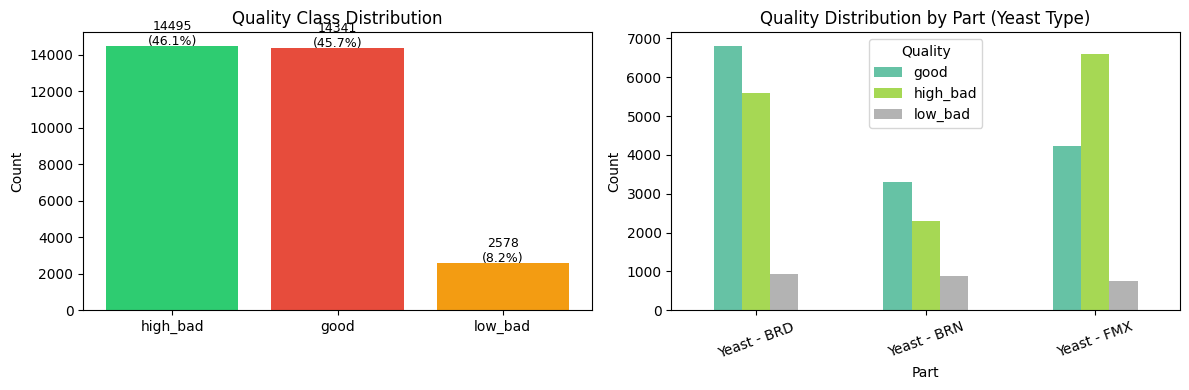


Part distribution:
Part
Yeast - BRD    13334
Yeast - FMX    11582
Yeast - BRN     6498
Name: count, dtype: int64

Quality × Part crosstab:
quality      good  high_bad  low_bad
Part                                
Yeast - BRD  6814      5583      937
Yeast - BRN  3298      2307      893
Yeast - FMX  4229      6605      748


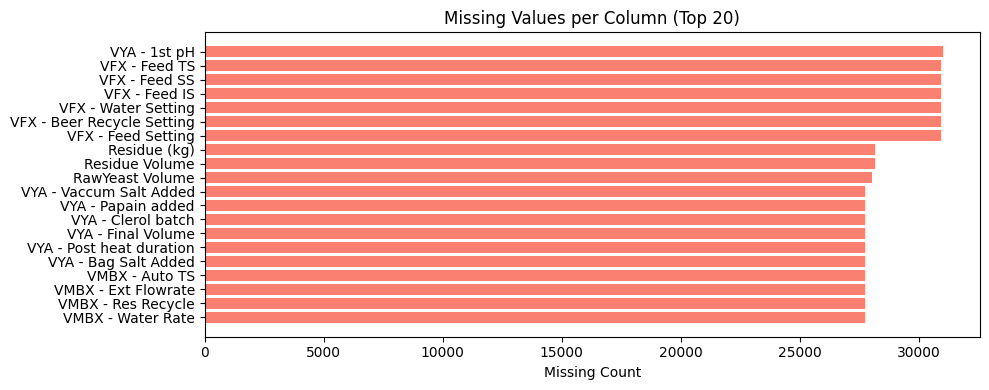


Missing values: 578789 total nulls in 20 columns

Numeric feature summary (sample):


,count,mean,std,min,25%,50%,75%,max
Value,14341.0,59.361,393.475,-89.00,-71.86,-49.72,73.00,3083.72
FFTE Feed solids SP,17073.0,47.801,7.054,25.00,50.00,50.00,50.00,50.00
FFTE Production solids SP,17073.0,41.886,1.413,39.00,40.84,43.00,43.00,43.00
FFTE Steam pressure SP,17073.0,113.999,22.149,10.00,104.00,116.00,128.00,850.00
TFE Out flow SP,17073.0,2523.441,377.923,1240.00,2214.29,2538.14,2846.51,3278.60
TFE Production solids SP,17073.0,64.494,11.592,0.00,63.00,66.00,71.00,90.00
TFE Vacuum pressure SP,17073.0,-65.647,15.222,-89.00,-79.47,-68.60,-51.80,-35.00
TFE Steam pressure SP,17073.0,118.147,12.745,2.00,120.00,120.00,120.00,135.00
VFX - Yeast Vat,3789.0,1.649,1.061,1.00,1.00,1.00,2.00,6.00
VFX - Feed TS,457.0,13.260,1.165,10.72,12.18,13.36,14.16,16.61


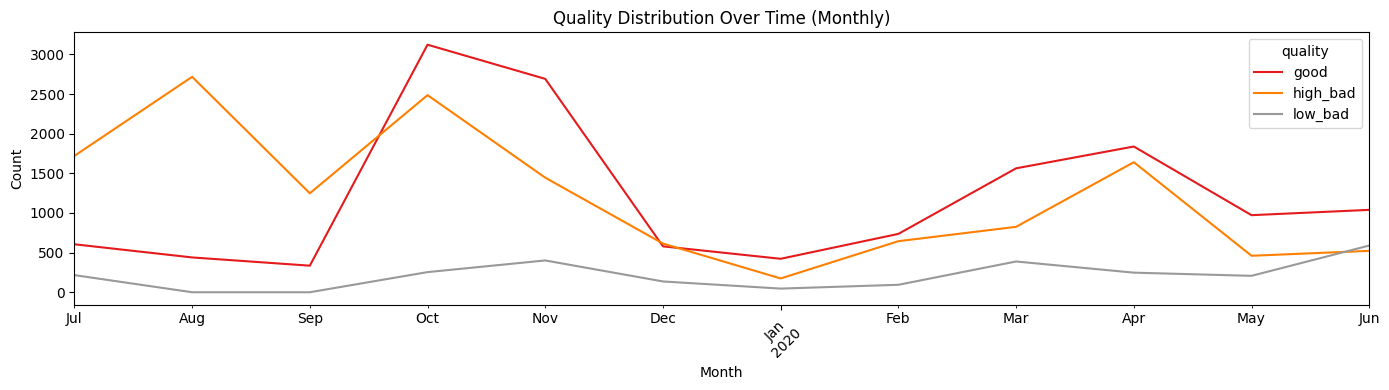

In [4]:
# ── Step 2: Exploratory Data Analysis (EDA) ──────────────────────────────────
print("=== 2. EDA ===")
print(f"Rows: {prod.shape[0]} | Columns: {prod.shape[1]}")
print(f"Date range: {prod['Timestamp'].min()} → {prod['Timestamp'].max()}")

# 2a. Quality class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

quality_counts = prod['quality'].value_counts()
axes[0].bar(quality_counts.index, quality_counts.values,
            color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Quality Class Distribution')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(quality_counts.items()):
    axes[0].text(i, cnt + 50, f'{cnt}\n({cnt/len(prod)*100:.1f}%)', ha='center', fontsize=9)

# 2b. Quality × Part
crosstab = pd.crosstab(prod['Part'], prod['quality'])
crosstab.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Quality Distribution by Part (Yeast Type)')
axes[1].set_xlabel('Part')
axes[1].set_ylabel('Count')
axes[1].legend(title='Quality')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print("\nPart distribution:")
print(prod['Part'].value_counts())
print("\nQuality × Part crosstab:")
print(pd.crosstab(prod['Part'], prod['quality']))

# 2c. Missing values
num_prod = prod.select_dtypes(include=[np.number])
missing = num_prod.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(20)
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing.index[::-1], missing.values[::-1], color='salmon')
    ax.set_title('Missing Values per Column (Top 20)')
    ax.set_xlabel('Missing Count')
    plt.tight_layout()
    plt.show()
    print(f"\nMissing values: {missing.sum()} total nulls in {len(missing)} columns")
else:
    print("\nNo missing values found.")

# 2d. Numeric feature summary
print("\nNumeric feature summary (sample):")
display(num_prod.describe().T.head(10).round(3))

# 2e. Time series quality trend
prod_monthly = prod.copy()
prod_monthly['month'] = prod_monthly['Timestamp'].dt.to_period('M')
monthly_qual = prod_monthly.groupby(['month', 'quality']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
monthly_qual.plot(ax=ax, colormap='Set1')
ax.set_title('Quality Distribution Over Time (Monthly)')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 3 & 4. Preprocessing and Feature Engineering

Applying median imputation and creating rolling/difference features to capture process dynamics per product part.

In [5]:
# ── Step 3+4: Preprocessing & Feature Engineering ────────────────────────────
print("=== Step 3: Preprocessing + Step 4: Feature Engineering ===")

# Apply feature engineering before preprocessing
prod_fe = add_engineered_features(prod)

fe_cols = [c for c in prod_fe.columns if '_roll3' in c or '_diff' in c]
print(f"Original columns : {prod.shape[1]}")
print(f"After FE columns : {prod_fe.shape[1]}")
print(f"New FE features  : {len(fe_cols)} (rolling mean + diff per Part)")

X_tr, X_val, X_te, y_tr, y_val, y_te, prod_fe, use_cols, le_q, medians, sp_cols = preprocessing(prod_fe)
print(f"\nFeatures used    : {len(use_cols)}")
print(f"SP columns       : {len(sp_cols)}")

=== Step 3: Preprocessing + Step 4: Feature Engineering ===
Original columns : 66
After FE columns : 90
New FE features  : 24 (rolling mean + diff per Part)
Dataset: 31414 rows | Train: 21989 | Val: 4712 | Test: 4713
Classes: ['good' 'high_bad' 'low_bad']

Features used    : 82
SP columns       : 12


---
## 5, 6 & 7. Model Training Pipeline

Execution of the training lifecycle: Chronological splitting, SMOTE resampling, and multi-algorithm benchmarking.

In [6]:
# ── Steps 5-7: Split → SMOTE → Train Multiple Models ─────────────────────────

# Global Model (all parts combined)
global_algo, m1, global_val_acc, global_val_f1, global_all_results = train_global_model(X_tr, y_tr, X_val, y_val)

# Per-Part Specialist Models
part_models = train_per_part_models(prod_fe, X_tr, y_tr, X_val, y_val, use_cols, le_q)

# Task 2: Downtime
m2 = train_downtime_model(prod_fe, downtime, use_cols, medians)

# Training Summary
print("\n====== TRAINING SUMMARY ======")
print(f"Global Model Best : {global_algo} (Val Acc: {global_val_acc:.4f}, F1: {global_val_f1:.4f})")
for part, m in part_models.items():
    print(f"Part [{part}] Best : {getattr(m, 'algo_name_', '?')}")


--- Global Quality Model Training ---
  Input size: 21989 rows -> Resampled size: 33183 rows

  Algorithm      Val Acc    Val F1
  --------------------------------
  RF              0.9351    0.7869
  CatBoost        0.9208    0.7202
  XGBoost         0.9147    0.6914
  LightGBM        0.9081    0.7166

  Selected Winner: RF (Accuracy=0.9351, F1=0.7869)

--- Per-Part Specialist Model Training ---

Processing: Yeast - BRD
  Training Set: 9818 -> 14667 | Validation Set: 1839

  Algorithm      Val Acc    Val F1
  --------------------------------
  CatBoost        0.8902    0.6257
  RF              0.8853    0.6092
  XGBoost         0.8717    0.5041
  LightGBM        0.8717    0.5041

  Selected Winner: CatBoost (Accuracy=0.8902, F1=0.6257)

Processing: Yeast - BRN
  Training Set: 4709 -> 6966 | Validation Set: 1147

  Algorithm      Val Acc    Val F1
  --------------------------------
  CatBoost        0.9983    0.9954
  RF              0.9669    0.9003
  XGBoost         0.9599    0.8746

---
## 8. Evaluation — Global Quality Model


 Global Quality Model [RF]
  Test Accuracy : 0.8313
  Test F1 Macro : 0.6563
  Test Samples  : 4713

              precision    recall  f1-score   support

        good       1.00      1.00      1.00      2314
    high_bad       0.66      1.00      0.79      1519
     low_bad       1.00      0.10      0.18       880

    accuracy                           0.83      4713
   macro avg       0.89      0.70      0.66      4713
weighted avg       0.89      0.83      0.78      4713



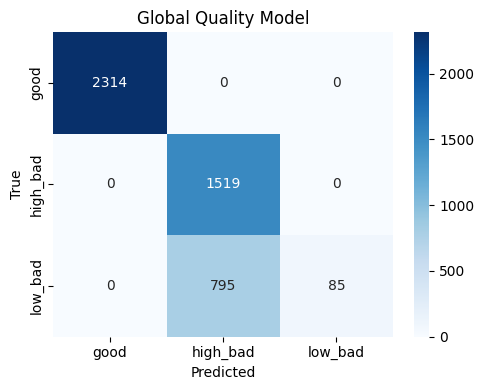


-- Global Model: Accuracy Breakdown per Part --
  Yeast - BRD: n=1677, Acc=0.9159, F1=0.7994
  Yeast - BRN: n=642, Acc=0.4626, F1=0.4437
  Yeast - FMX: n=2394, Acc=0.8709, F1=0.6215


In [7]:
# ── Step 8: Evaluation — Global Model ────────────────────────────────────────
evaluate_model(m1, X_te, y_te, le_q, title="Global Quality Model")

print("\n-- Global Model: Accuracy Breakdown per Part --")
df_te = prod_fe.iloc[len(prod_fe)-len(y_te):]
for part in sorted(prod_fe['Part'].unique()):
    mask = (df_te['Part'] == part).values
    if mask.sum() > 0:
        preds = m1.predict(X_te.values[mask])
        acc = accuracy_score(y_te[mask], preds)
        f1 = f1_score(y_te[mask], preds, average='macro', zero_division=0)
        n = mask.sum()
        print(f"  {part}: n={n}, Acc={acc:.4f}, F1={f1:.4f}")

---
## 8 & 9. Evaluation and Model Comparison — Specialist Models


--- Per-Part Specialist Models: Test Evaluation ---

 Part: Yeast - BRD [CatBoost]
  Test Accuracy : 0.9141
  Test F1 Macro : 0.8279
  Test Samples  : 1677

              precision    recall  f1-score   support

        good       1.00      1.00      1.00       998
    high_bad       0.81      0.90      0.85       458
     low_bad       0.73      0.56      0.63       221

    accuracy                           0.91      1677
   macro avg       0.84      0.82      0.83      1677
weighted avg       0.91      0.91      0.91      1677



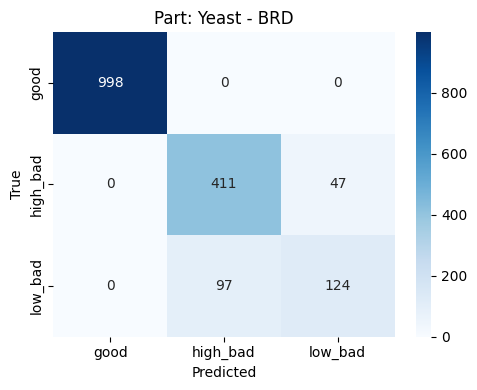


 Part: Yeast - BRN [CatBoost]
  Test Accuracy : 0.4548
  Test F1 Macro : 0.4333
  Test Samples  : 642

              precision    recall  f1-score   support

        good       1.00      1.00      1.00       217
    high_bad       0.18      1.00      0.30        75
     low_bad       0.00      0.00      0.00       350

    accuracy                           0.45       642
   macro avg       0.39      0.67      0.43       642
weighted avg       0.36      0.45      0.37       642



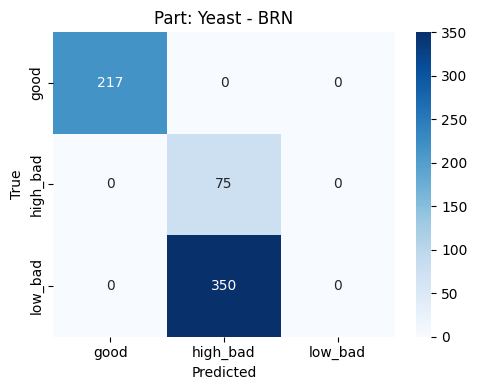


 Part: Yeast - FMX [XGBoost]
  Test Accuracy : 0.8158
  Test F1 Macro : 0.5913
  Test Samples  : 2394

              precision    recall  f1-score   support

        good       0.87      1.00      0.93      1099
    high_bad       0.78      0.86      0.82       986
     low_bad       0.09      0.01      0.02       309

    accuracy                           0.82      2394
   macro avg       0.58      0.63      0.59      2394
weighted avg       0.73      0.82      0.77      2394



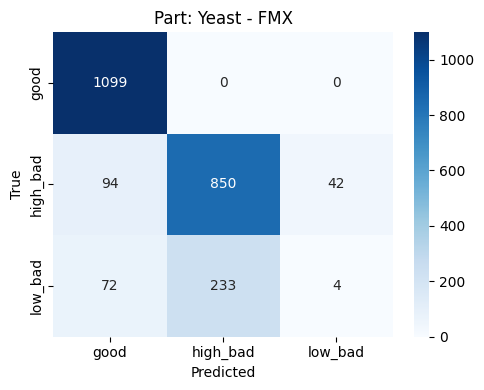


--- Model Comparison: Global vs Specialist ---
Part                  Global Acc  Specialist Acc
------------------------------------------------
  Yeast - BRD              0.9159         0.9141  [Global]
  Yeast - BRN              0.4626         0.4548  [Global]
  Yeast - FMX              0.8709         0.8158  [Global]


In [8]:
# 1. Evaluation: Per-Part Specialist Models
print("\n--- Per-Part Specialist Models: Test Evaluation ---")
df_te = prod_fe.iloc[len(prod_fe)-len(y_te):]

part_accs = {}
for part, model in part_models.items():
    mask = (df_te['Part'] == part).values
    if mask.sum() == 0: continue
    X_p_te = X_te.iloc[np.where(mask)[0]]
    y_p_te = y_te[mask]
    result = evaluate_model(model, X_p_te, y_p_te, le_q, title=f"Part: {part}")
    if result: part_accs[part] = result[0]

# 2. Model Comparison: Global vs Per-Part
print("\n--- Model Comparison: Global vs Specialist ---")
print(f"{'Part':<20} {'Global Acc':>11} {'Specialist Acc':>15}")
print(f"{'-'*48}")
df_te = prod_fe.iloc[len(prod_fe)-len(y_te):]
for part in sorted(prod_fe['Part'].unique()):
    mask = (df_te['Part'] == part).values
    if mask.sum() == 0: continue
    # Global
    g_preds = m1.predict(X_te.values[mask])
    g_acc = accuracy_score(y_te[mask], g_preds)
    # Specialist
    s_acc = part_accs.get(part, 0)
    winner = "[Global]" if g_acc > s_acc else "[Specialist]"
    print(f"  {part:<20} {g_acc:>10.4f} {s_acc:>14.4f}  {winner}")

---
## 8. Evaluation — Downtime Detection Model


--- Downtime Evaluation: Test Set ---
  Test Accuracy : 0.9996
  Test ROC-AUC  : 1.0000

              precision    recall  f1-score   support

 no_downtime       1.00      1.00      1.00      1051
    downtime       1.00      1.00      1.00      3662

    accuracy                           1.00      4713
   macro avg       1.00      1.00      1.00      4713
weighted avg       1.00      1.00      1.00      4713



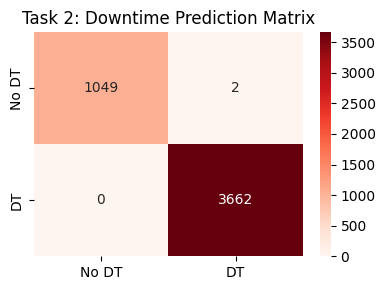

In [9]:
# 3. Evaluation: Downtime Model
if m2 is not None:
    print("\n--- Downtime Evaluation: Test Set ---")
    df_te = prod_fe.iloc[len(prod_fe)-len(y_te):]
    if 'downtime_target' in df_te.columns:
        y_dt_te = df_te['downtime_target'].values
        y_dt_pred = m2.predict(X_te.values)
        y_dt_prob = m2.predict_proba(X_te.values)[:, 1]
        print(f"  Test Accuracy : {accuracy_score(y_dt_te, y_dt_pred):.4f}")
        try: print(f"  Test ROC-AUC  : {roc_auc_score(y_dt_te, y_dt_prob):.4f}")
        except: pass
        print()
        print(classification_report(y_dt_te, y_dt_pred, target_names=['no_downtime', 'downtime'], zero_division=0))
        cm = confusion_matrix(y_dt_te, y_dt_pred)
        fig, ax = plt.subplots(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                    xticklabels=['No DT', 'DT'], yticklabels=['No DT', 'DT'], ax=ax)
        ax.set_title("Task 2: Downtime Prediction Matrix")
        plt.tight_layout()
        plt.show()
else:
    print("Downtime prediction model was not trained.")

---
## 10. Feature Importance

Analysis of sensor contributions and root-cause drivers for quality outcomes.

=== Step 10: Feature Importance ===

-- Global Model --


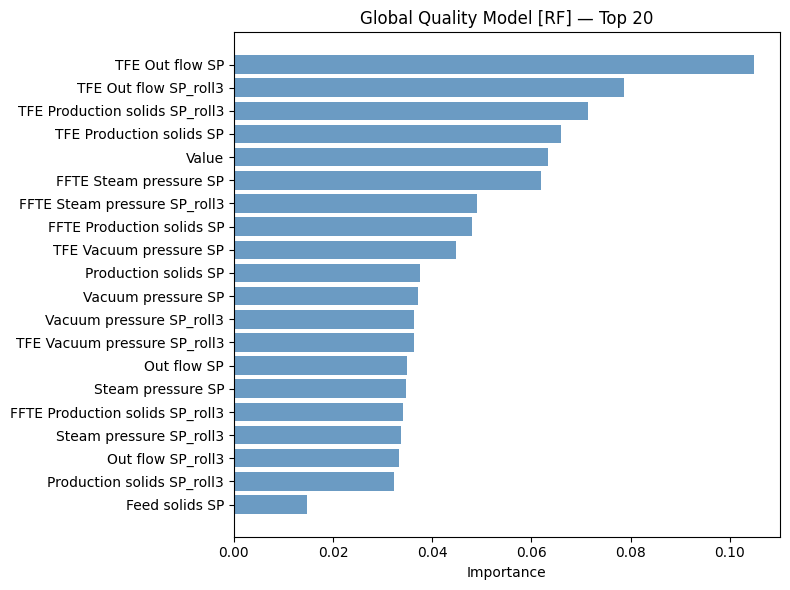

  Top 5 features:
    TFE Out flow SP                          0.1049
    TFE Out flow SP_roll3                    0.0786
    TFE Production solids SP_roll3           0.0714
    TFE Production solids SP                 0.0659
    Value                                    0.0634

-- Part: Yeast - BRD --


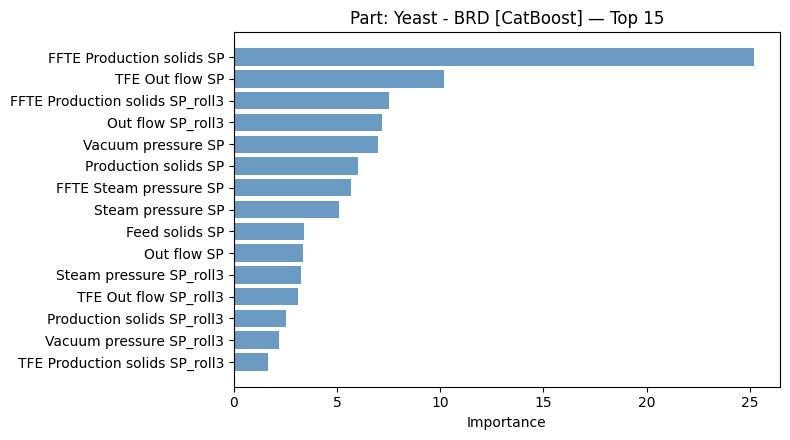

  Top 5 features:
    FFTE Production solids SP                25.2096
    TFE Out flow SP                          10.1911
    FFTE Production solids SP_roll3          7.5289
    Out flow SP_roll3                        7.1918
    Vacuum pressure SP                       6.9727

-- Part: Yeast - BRN --


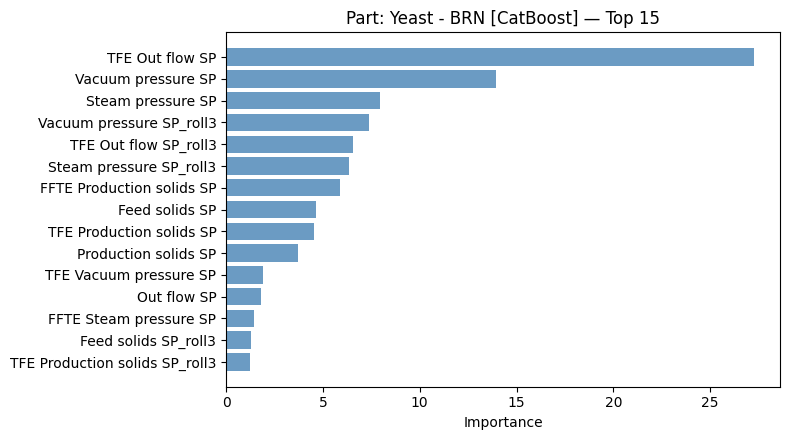

  Top 5 features:
    TFE Out flow SP                          27.2409
    Vacuum pressure SP                       13.9285
    Steam pressure SP                        7.9681
    Vacuum pressure SP_roll3                 7.3844
    TFE Out flow SP_roll3                    6.5498

-- Part: Yeast - FMX --


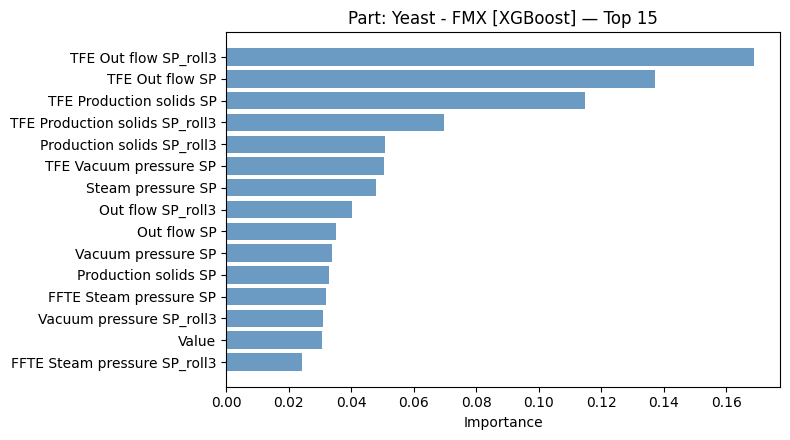

  Top 5 features:
    TFE Out flow SP_roll3                    0.1687
    TFE Out flow SP                          0.1372
    TFE Production solids SP                 0.1149
    TFE Production solids SP_roll3           0.0697
    Production solids SP_roll3               0.0507


In [10]:
# ── Step 10: Feature Importance ──────────────────────────────────────────────
print("=== Step 10: Feature Importance ===")

# Global model feature importance
print("\n-- Global Model --")
plot_feature_importance(m1, use_cols, title="Global Quality Model", top_n=20)

# Per-Part feature importance
for part, model in part_models.items():
    print(f"\n-- Part: {part} --")
    plot_feature_importance(model, use_cols, title=f"Part: {part}", top_n=15)

---
## 11. Model Persistence

Saving finalized models and configuration artifacts for production use.

In [11]:
# 11. Model Persistence
import json

OUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "./output"
os.makedirs(OUT_DIR, exist_ok=True)

joblib.dump(m1, os.path.join(OUT_DIR, "vegemite_quality_global.joblib"))
joblib.dump(part_models, os.path.join(OUT_DIR, "vegemite_quality_specialists.joblib"))
if m2: joblib.dump(m2, os.path.join(OUT_DIR, "vegemite_downtime.joblib"))
joblib.dump({'le_q': le_q, 'use_cols': use_cols, 'sp_cols': sp_cols, 'medians': medians},
            os.path.join(OUT_DIR, "vegemite_artifacts.joblib"))

model_info = {
    "project": "Vegemite Quality Prediction",
    "classes": list(le_q.classes_),
    "features_count": len(use_cols),
    "global_algorithm": getattr(m1, 'algo_name_', '?'),
    "specialist_algorithms": {k: getattr(v, 'algo_name_', '?') for k, v in part_models.items()},
    "downtime_model": str(type(m2).__name__) if m2 else None,
    "steps": [
        "1. Data Loading",
        "2. EDA",
        "3. Preprocessing",
        "4. Feature Engineering",
        "5. Train/Test Split",
        "6. Handle Imbalance",
        "7. Model Training",
        "8. Evaluation",
        "9. Model Comparison",
        "10. Feature Importance",
        "11. Model Persistence"
    ]
}
with open(os.path.join(OUT_DIR, "model_info.json"), 'w') as f:
    json.dump(model_info, f, indent=2)

print("Artifacts saved successfully to:", OUT_DIR)
print("Files:", sorted(f for f in os.listdir(OUT_DIR) if f.startswith('vegemite')))
print("\n--- Pipeline Execution Complete ---")
for step in model_info["steps"]:
    print(f"  [X] {step}")

Artifacts saved successfully to: /kaggle/working
Files: ['vegemite_artifacts.joblib', 'vegemite_downtime.joblib', 'vegemite_quality_global.joblib', 'vegemite_quality_specialists.joblib']

--- Pipeline Execution Complete ---
  [X] 1. Data Loading
  [X] 2. EDA
  [X] 3. Preprocessing
  [X] 4. Feature Engineering
  [X] 5. Train/Test Split
  [X] 6. Handle Imbalance
  [X] 7. Model Training
  [X] 8. Evaluation
  [X] 9. Model Comparison
  [X] 10. Feature Importance
  [X] 11. Model Persistence
